In [2]:
import locale

locale.getpreferredencoding = lambda: "UTF-8"

In [2]:
!pip install ultralytics==8.2.80 -q
!pip install opencv-python==4.10.0.84 -q
!pip install matplotlib -q

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
moviepy 2.1.2 requires pillow<11.0,>=9.2.0, but you have pillow 11.1.0 which is incompatible.


In [3]:
pip show ultralytics

Name: ultralytics
Version: 8.2.80
Summary: Ultralytics YOLOv8 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation and image classification.
Home-page: 
Author: Glenn Jocher, Ayush Chaurasia, Jing Qiu
Author-email: 
License: AGPL-3.0
Location: C:\Users\dell\miniconda3\envs\opencv-env\Lib\site-packages
Requires: matplotlib, numpy, opencv-python, pandas, pillow, psutil, py-cpuinfo, pyyaml, requests, scipy, seaborn, torch, torchvision, tqdm, ultralytics-thop
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.80  Python-3.11.13 torch-2.8.0+cpu CPU (Intel Core(TM) i5-8250U 1.60GHz)
Setup complete  (8 CPUs, 7.9 GB RAM, 8.9/320.0 GB disk)


In [5]:
import os
import numpy as np
import cv2
import sys
import time
import requests
import zipfile
from os import path
import matplotlib.pyplot as plt

In [6]:
from ultralytics.utils import yaml_load
from ultralytics.utils.checks import check_yaml

In [18]:
def download_and_unzip(dropbox_link):
    
    output_dir = 'content'
    
    filename = dropbox_link.split('/')[-1]

    response = requests.get(dropbox_link)

    zip_path = os.path.join(output_dir, filename)

    with open(zip_path, 'wb') as f:
        f.write(response.content)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)

    os.remove(zip_path)

    print(f"Zip file download and extracted to :{output_dir}")  

In [19]:
dropbox_link = "https://www.dropbox.com/scl/fi/exg6o6greg7cp2uq98wll/yolov8-opencvdnn.zip?rlkey=2br0c8r1fjrqgyf6i362xfxrd&st=9lmmh6t5&dl=1"

In [26]:
dropbox_link.split('/')

['https:',
 '',
 'www.dropbox.com',
 'scl',
 'fi',
 'exg6o6greg7cp2uq98wll',
 'yolov8-opencvdnn.zip?rlkey=2br0c8r1fjrqgyf6i362xfxrd&st=9lmmh6t5&dl=1']

In [7]:
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14

In [8]:
from ultralytics import YOLO
model = YOLO("yolov8s.pt")

In [9]:
model.export(format='onnx')

Ultralytics YOLOv8.2.80  Python-3.11.13 torch-2.8.0+cpu CPU (Intel Core(TM) i5-8250U 1.60GHz)
YOLOv8s summary (fused): 168 layers, 11,156,544 parameters, 0 gradients, 28.6 GFLOPs

PyTorch: starting from 'yolov8s.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (21.5 MB)

ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: export success  2.7s, saved as 'yolov8s.onnx' (42.8 MB)

Export complete (6.2s)
Results saved to G:\OpenCV\module15-object-detection-YOLOv5\module15-object-detection\MyPractice
Predict:         yolo predict task=detect model=yolov8s.onnx imgsz=640  
Validate:        yolo val task=detect model=yolov8s.onnx imgsz=640 data=coco.yaml  
Visualize:       https://netron.app


'yolov8s.onnx'

In [10]:
INPUT_WIDTH = 640
INPUT_HEIGHT = 640
CONFIDENCE_THRESHOLD = 0.5
NMS_THRESHOLD = 0.3

In [11]:
FONT_FACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 1
THICKNESS = 2

In [12]:
from ultralytics.utils import yaml_load
from ultralytics.utils.checks import check_yaml

In [13]:
CLASSES = yaml_load(check_yaml("coco8.yaml"))["names"]

In [14]:
for cla in CLASSES.values():
    print(cla)

person
bicycle
car
motorcycle
airplane
bus
train
truck
boat
traffic light
fire hydrant
stop sign
parking meter
bench
bird
cat
dog
horse
sheep
cow
elephant
bear
zebra
giraffe
backpack
umbrella
handbag
tie
suitcase
frisbee
skis
snowboard
sports ball
kite
baseball bat
baseball glove
skateboard
surfboard
tennis racket
bottle
wine glass
cup
fork
knife
spoon
bowl
banana
apple
sandwich
orange
broccoli
carrot
hot dog
pizza
donut
cake
chair
couch
potted plant
bed
dining table
toilet
tv
laptop
mouse
remote
keyboard
cell phone
microwave
oven
toaster
sink
refrigerator
book
clock
vase
scissors
teddy bear
hair drier
toothbrush


In [15]:
COLORS = np.random.uniform(0,255,size=(len(CLASSES),3))

In [17]:
def draw_detections(img, box, score, class_id):
    x1, y1, w, h = box

    color = COLORS[class_id]

    cv2.rectangle(img, (int(x1),int(y1)),(int(x1 + w),int(y1 + h)),color,2)

    label = f"{CLASSES[class_id]} : {score:.2f}"

    (label_width, label_height), _ = cv2.getTextSize(label, FONT_FACE, FONT_SCALE, THICKNESS)

    label_x = x1
    label_y = y1 - 10 if y1 - 10 > label_height else y1 + 10

    cv2.rectangle(img, (label_x, label_y - label_height),(label_x + label_width, label_y + label_height),color, cv2.FILLED)

    cv2.putText(img, label, (label_x, label_y), FONT_FACE, FONT_SCALE, (0,0,0), THICKNESS, cv2.LINE_AA)

##############################

In [18]:
def inference(input_image, net):
    blob = cv2.dnn.blobFromImage(input_image, 1/255, (INPUT_WIDTH, INPUT_HEIGHT), [0,0,0], 1, crop=False)

    net.setInput(blob)

    output_layers = net.getUnconnectedOutLayersNames()
    image_data = net.forward(output_layers)

    return image_data

###################


In [19]:
def post_process(input_image, output):
    outputs = np.transpose(np.squeeze(output[0]))

    rows = outputs.shape[0]

    boxes = []

    scores = []

    class_ids = []

    img_height, img_width = input_image.shape[:2]

    x_factor = img_width / INPUT_WIDTH
    y_factor = img_height / INPUT_HEIGHT

    for i in range(rows):
        classes_score = outputs[i][4:]
        max_score = np.amax(classes_score)
        if max_score > CONFIDENCE_THRESHOLD:
            class_id = np.argmax(classes_score)

            x,y,w,h = outputs[i][0], outputs[i][1], outputs[i][2], outputs[i][3]

            left = int((x - w / 2) * x_factor)
            top = int((y - h / 2) * y_factor)
            width = int( w * x_factor)
            height = int( h * y_factor)

            class_ids.append(class_id)
            scores.append(max_score)
            boxes.append([left, top, width, height])

    indices = cv2.dnn.NMSBoxes(boxes, scores, CONFIDENCE_THRESHOLD, NMS_THRESHOLD)

    for i in indices:
        box = boxes[i]
        score = scores[i]
        class_id = class_ids[i]

        draw_detections(input_image, box, score, class_id)
    return input_image

In [20]:
def put_efficiency(input_image, inference_time, is_video=False):
    if is_video:
        fps = 1 / inference_time
        label = 'FPS: %.2f' % fps

    else:
        label = 'Inference Time: %.2f ms' % (inference_time * 1000.0)
        
    cv2.putText(input_image, label, (10,50), FONT_FACE, FONT_SCALE, (0,255,0), THICKNESS, cv2.LINE_AA)
    

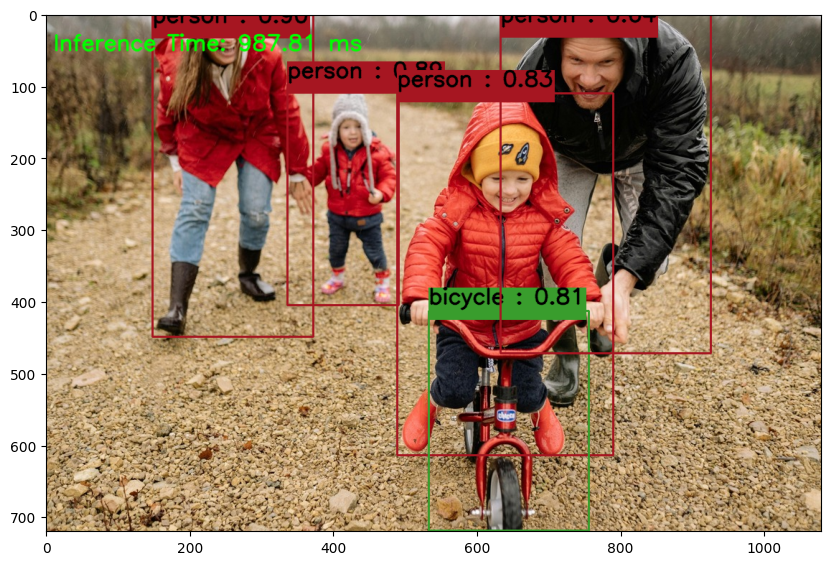

In [21]:
frame = cv2.imread('../family.jpg', cv2.IMREAD_COLOR)

model = 'yolov8s.onnx'
net = cv2.dnn.readNetFromONNX(model)

start_time = time.time()

detections = inference(frame, net)

inference_time = time.time() - start_time 

img = post_process(frame.copy(), detections)

put_efficiency(img, inference_time, is_video=False)

cv2.imwrite("result_v9.jpg",img)

plt.imshow(img[...,::-1])
plt.show()

In [24]:
model = 'yolov8s.onnx'

net = cv2.dnn.readNetFromONNX(model)

video_path = '../birds-side-view.mp4'

cap = cv2.VideoCapture(video_path)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

output_path = 'output_video_1.mp4'

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))
while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        print("End of Video Stream")
        break

    start_time = time.time()

    detections = inference(frame, net)
    inference_time = time.time() - start_time
    img = post_process(frame.copy(), detections)
    put_efficiency(img, inference_time, is_video = True)
    

    out.write(img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

End of Video Stream


In [ ]:
from IPython.display import Video

Video(output_video.mp4)